In [ ]:
!pip install -q transformers datasets evaluate scikit-learn accelerate seaborn

In [ ]:
import torch
import numpy as np
import pandas as pd
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    TrainerCallback
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import evaluate

In [ ]:
dataset = load_dataset("dair-ai/emotion")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

ROOT_RESULTS = "./results_graphs/"
os.makedirs(ROOT_RESULTS, exist_ok=True)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=preds, references=labels)

    precision = precision_metric.compute(
        predictions=preds,
        references=labels,
        average=None
    )

    recall = recall_metric.compute(
        predictions=preds,
        references=labels,
        average=None
    )

    f1 = f1_metric.compute(
        predictions=preds,
        references=labels,
        average=None
    )

    return {
        "accuracy": acc["accuracy"],
        "precision": precision["precision"].tolist(),
        "recall": recall["recall"].tolist(),
        "f1": f1["f1"].tolist()
    }

In [ ]:
class TrainingMonitor(TrainerCallback):

    def __init__(self, name):
        self.name = name
        self.train_loss = []
        self.eval_loss = []
        self.train_epochs = []
        self.eval_epochs = []
        self.grad_norm = []

    def on_log(self, args, state, control, logs=None, **kwargs):

        if logs is None:
            return

        if "loss" in logs:
            self.train_loss.append(logs["loss"])
            self.train_epochs.append(state.epoch)
            self.grad_norm.append(logs.get("grad_norm", 0))

        if "eval_loss" in logs:
            self.eval_loss.append(logs["eval_loss"])
            self.eval_epochs.append(state.epoch)

    def save_plots(self):

        sns.set_theme(style="darkgrid")

        # LOSS
        df_train = pd.DataFrame({
            "Epoch": self.train_epochs,
            "Loss": self.train_loss,
            "Type": "Training"
        })

        df_all = df_train

        if len(self.eval_loss) > 0:
            df_eval = pd.DataFrame({
                "Epoch": self.eval_epochs,
                "Loss": self.eval_loss,
                "Type": "Validation"
            })
            df_all = pd.concat([df_train, df_eval])

        fig = sns.lineplot(data=df_all, x="Epoch", y="Loss", hue="Type")
        fig.figure.savefig(ROOT_RESULTS + f"{self.name}_loss.png", dpi=400)
        fig.figure.clf()

        # GRAD NORM
        df_grad = pd.DataFrame({
            "Epoch": self.train_epochs,
            "Gradient Norm": self.grad_norm
        })

        fig2 = sns.lineplot(data=df_grad, x="Epoch", y="Gradient Norm")
        fig2.figure.savefig(ROOT_RESULTS + f"{self.name}_gradnorm.png", dpi=400)
        fig2.figure.clf()


In [ ]:
def plot_class_metrics(eval_results, class_names, filename):

    df = pd.DataFrame({
        "Class": class_names,
        "Precision": eval_results["precision"],
        "Recall": eval_results["recall"],
        "F1": eval_results["f1"]
    })

    df_melted = df.melt(
        id_vars="Class",
        value_vars=["Precision", "Recall", "F1"],
        var_name="Metric",
        value_name="Score"
    )

    sns.set_theme(style="whitegrid")

    fig = sns.catplot(
        data=df_melted,
        kind="bar",
        x="Class",
        y="Score",
        hue="Metric",
        height=6,
        aspect=1.5
    )

    fig.set(ylim=(0,1))
    fig.savefig(ROOT_RESULTS + filename, dpi=400)

In [ ]:
def plot_confusion_matrix_func(predictions, true_P, filename):
    """
    Crea e salva una confusion matrix.

    Parameters:
        predictions (np.array): array delle previsioni del modello.
        labels (np.array): array delle etichette reali.
        class_names (list): lista dei nomi delle classi.
        filename (str): nome del file immagine da salvare.
    """
    cm = confusion_matrix(true_P, predictions)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.grid(False)

    ax.set_title(f"Confusion Matrix ({filename})")
    plt.savefig(ROOT_RESULTS + f"Confusion_Matrix_{filename}.png", dpi=600, bbox_inches="tight")
    plt.close()
    print(f"Confusion matrix salvata come Confusion_Matrix_{filename}.png")

In [ ]:
print("--- LIGHT FINE-TUNING ---")

model_light = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)

for param in model_light.parameters():
    param.requires_grad = False

for param in model_light.classifier.parameters():
    param.requires_grad = True

train_light = tokenized_dataset["train"].train_test_split(
    train_size=0.35,
    seed=42
)["train"]

monitor_light = TrainingMonitor("Light_FT")

training_args_light = TrainingArguments(
    output_dir="./results_light",
    num_train_epochs=15,
    learning_rate=3e-3,
    weight_decay=0.01,
    per_device_train_batch_size=16,
    eval_strategy="steps",
    eval_steps=250,
    logging_steps=250,
    report_to="none"
)

trainer_light = Trainer(
    model=model_light,
    args=training_args_light,
    train_dataset=train_light,
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[monitor_light]
)

trainer_light.train()
monitor_light.save_plots()

--- LIGHT FINE-TUNING ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
250,1.543863,1.498099,0.393000,"[0.3225605966438782, 0.6828644501278772, 0.0, 0.0, 0.0, 0.0]","[0.9436363636363636, 0.37926136363636365, 0.0, 0.0, 0.0, 0.0]","[0.4807781380268643, 0.4876712328767123, 0.0, 0.0, 0.0, 0.0]"
500,1.452690,1.456644,0.411500,"[0.33354673495518566, 0.6894977168949772, 0.0, 0.0, 0.0, 0.0]","[0.9472727272727273, 0.4289772727272727, 0.0, 0.0, 0.0, 0.0]","[0.4933712121212121, 0.5288966725043783, 0.0, 0.0, 0.0, 0.0]"
750,1.404823,1.363341,0.496500,"[0.4554334554334554, 0.5230635335073978, 0.5, 0.6363636363636364, 0.5789473684210527, 0.0]","[0.6781818181818182, 0.8536931818181818, 0.0056179775280898875, 0.025454545454545455, 0.05188679245283019, 0.0]","[0.5449233016800584, 0.6486778197517539, 0.011111111111111112, 0.04895104895104895, 0.09523809523809523, 0.0]"
1000,1.367406,1.363521,0.510000,"[0.42953020134228187, 0.5989247311827957, 0.0, 0.6666666666666666, 0.4166666666666667, 0.0]","[0.8145454545454546, 0.7911931818181818, 0.0, 0.03636363636363636, 0.02358490566037736, 0.0]","[0.5624607658505963, 0.6817625458996328, 0.0, 0.06896551724137931, 0.044642857142857144, 0.0]"
1250,1.353991,1.355715,0.476500,"[0.37829691032403917, 0.6711711711711712, 0.6666666666666666, 0.3333333333333333, 1.0, 0.0]","[0.9127272727272727, 0.6349431818181818, 0.011235955056179775, 0.0036363636363636364, 0.0047169811320754715, 0.0]","[0.5348961108151306, 0.6525547445255474, 0.022099447513812154, 0.007194244604316547, 0.009389671361502348, 0.0]"
1500,1.341296,1.328275,0.525000,"[0.4517133956386293, 0.6159822419533851, 0.5, 0.6296296296296297, 0.3883495145631068, 0.0]","[0.7909090909090909, 0.7883522727272727, 0.016853932584269662, 0.06181818181818182, 0.18867924528301888, 0.0]","[0.5750165234633179, 0.6915887850467289, 0.03260869565217391, 0.11258278145695365, 0.25396825396825395, 0.0]"
1750,1.334032,1.323733,0.507500,"[0.411006018916595, 0.6531645569620254, 0.6666666666666666, 0.5555555555555556, 0.4, 0.0]","[0.8690909090909091, 0.7329545454545454, 0.011235955056179775, 0.01818181818181818, 0.0660377358490566, 0.0]","[0.5580852305896089, 0.6907630522088354, 0.022099447513812154, 0.035211267605633804, 0.11336032388663968, 0.0]"
2000,1.318323,1.315834,0.504000,"[0.40486169321039395, 0.6576576576576577, 0.75, 0.42857142857142855, 0.4444444444444444, 0.0]","[0.8781818181818182, 0.7258522727272727, 0.016853932584269662, 0.01090909090909091, 0.03773584905660377, 0.0]","[0.5542168674698795, 0.6900742741390952, 0.03296703296703297, 0.02127659574468085, 0.06956521739130435, 0.0]"
2250,1.338005,1.310291,0.523500,"[0.4483111566018424, 0.6054054054054054, 0.6666666666666666, 0.7058823529411765, 0.44871794871794873, 0.0]","[0.7963636363636364, 0.7954545454545454, 0.011235955056179775, 0.04363636363636364, 0.1650943396226415, 0.0]","[0.5736738703339882, 0.6875383670963782, 0.022099447513812154, 0.0821917808219178, 0.2413793103448276, 0.0]"
2500,1.313576,1.305039,0.528000,"[0.4365530303030303, 0.6569250317662008, 0.75, 0.5180722891566265, 0.45714285714285713, 0.0]","[0.8381818181818181, 0.734375, 0.016853932584269662, 0.15636363636363637, 0.1509433962264151, 0.0]","[0.5740971357409713, 0.6934942991281019, 0.03296703296703297, 0.24022346368715083, 0.22695035460992907, 0.0]"


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

---- IN-CONTEXT EVALUATION ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion matrix salvata come Confusion_Matrix_one_shot_light_confusion_matrix.png


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



ONE_SHOT RESULTS
{'eval_loss': 1.4931516647338867, 'eval_accuracy': 0.4805, 'eval_precision': [0.4574898785425101, 0.5577342047930284, 0.0, 0.0, 0.3235294117647059, 0.0], 'eval_recall': [0.5834767641996558, 0.7366906474820144, 0.0, 0.0, 0.49107142857142855, 0.0], 'eval_f1': [0.5128593040847201, 0.6348419094854308, 0.0, 0.0, 0.3900709219858156, 0.0], 'eval_runtime': 7.4983, 'eval_samples_per_second': 266.727, 'eval_steps_per_second': 33.341, 'epoch': 15.0}


...


THREE_SHOT RESULTS
{'eval_loss': 1.4422318935394287, 'eval_accuracy': 0.454, 'eval_precision': [0.5102974828375286, 0.43495400788436267, 0.0, 0.0, 0.5609756097560976, 0.0], 'eval_recall': [0.3838209982788296, 0.9525179856115108, 0.0, 0.0, 0.10267857142857142, 0.0], 'eval_f1': [0.4381139489194499, 0.5972034280559314, 0.0, 0.0, 0.17358490566037735, 0.0], 'eval_runtime': 7.7183, 'eval_samples_per_second': 259.123, 'eval_steps_per_second': 32.39, 'epoch': 15.0}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion matrix salvata come Confusion_Matrix_five_shot_light_confusion_matrix.png


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



FIVE_SHOT RESULTS
{'eval_loss': 1.5297932624816895, 'eval_accuracy': 0.473, 'eval_precision': [0.4151624548736462, 0.6433333333333333, 0.0, 0.0, 0.3424657534246575, 0.0], 'eval_recall': [0.7917383820998278, 0.5553956834532374, 0.0, 0.0, 0.44642857142857145, 0.0], 'eval_f1': [0.5447010065127295, 0.5961389961389961, 0.0, 0.0, 0.3875968992248062, 0.0], 'eval_runtime': 7.4829, 'eval_samples_per_second': 267.276, 'eval_steps_per_second': 33.409, 'epoch': 15.0}


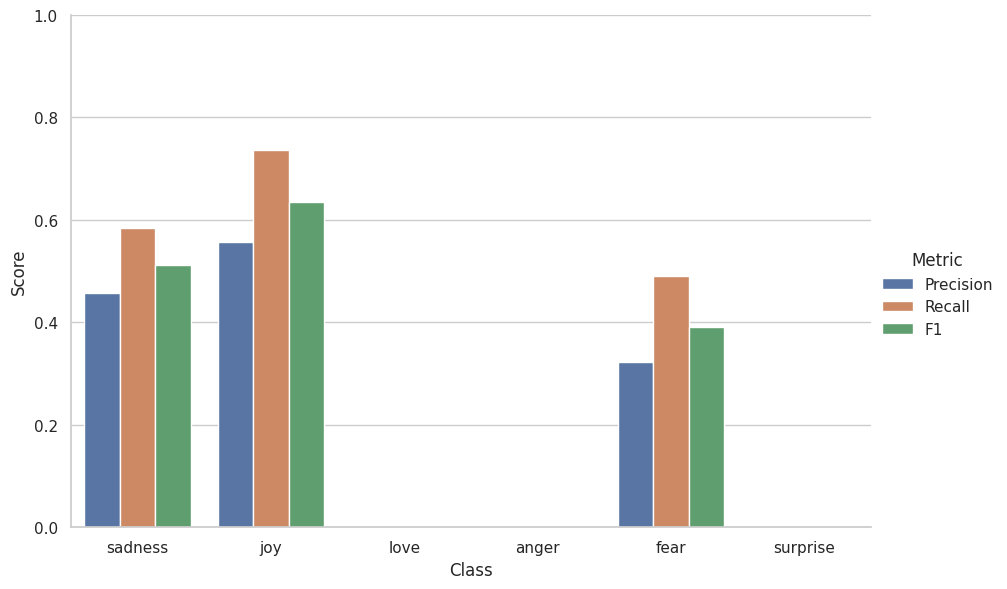

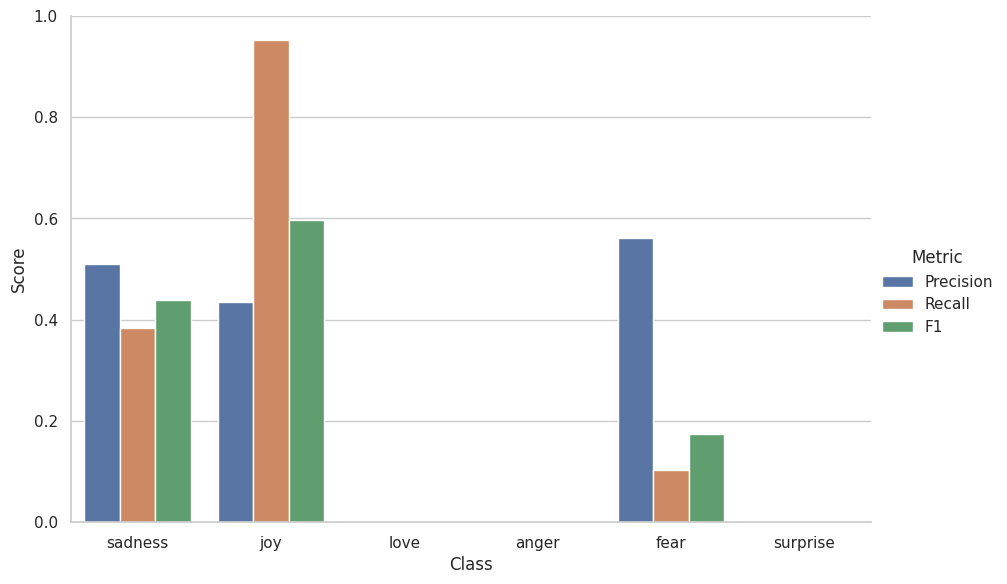

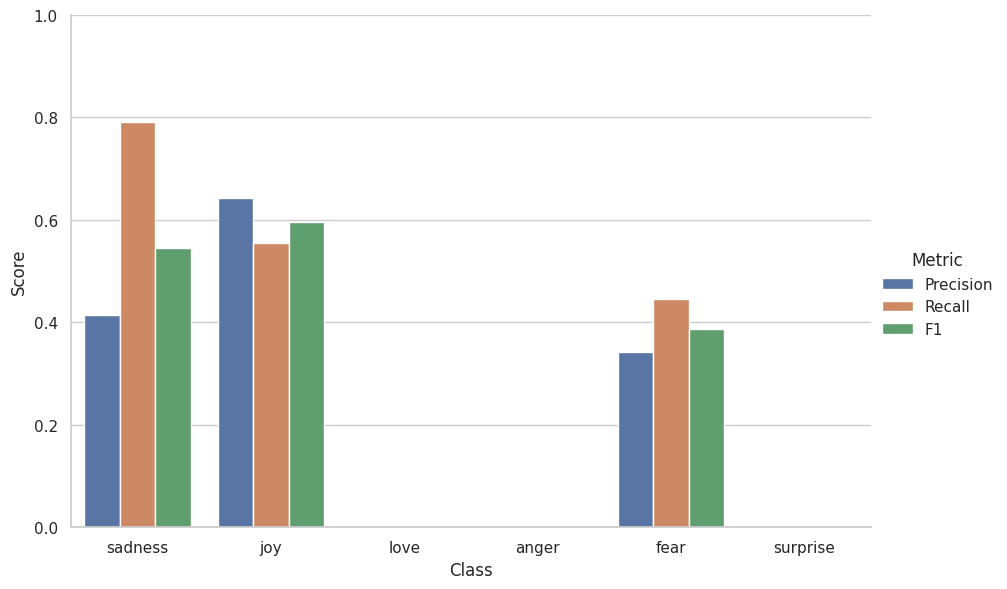

In [ ]:
print("---- IN-CONTEXT EVALUATION ---")

one_shot = """
Classify the sentence based on emotion:

i feel empty and exhausted, like nothing i do matters anymore => 0
"""

three_shot = one_shot + """
today i woke up smiling because everything is going right => 1
i feel deeply connected to you and grateful to have you => 2
"""

five_shot = three_shot + """
it makes me furious when people ignore my efforts => 3
my heart started racing when i lost my passport => 4
"""

def build_context_dataset(prompt):
    return dataset["test"].map(
        lambda x: {"text": prompt + x["text"] + " =>", "label": x["label"]}
    ).map(tokenize_function, batched=True)

context_sets = {
    "one_shot": build_context_dataset(one_shot),
    "three_shot": build_context_dataset(three_shot),
    "five_shot": build_context_dataset(five_shot)
}

for name, ds_ctx in context_sets.items():

    ds_ctx.set_format(type="torch",
                      columns=["input_ids", "attention_mask", "label"])

    preds = trainer_light.predict(ds_ctx)
    pred_labels = np.argmax(preds.predictions, axis=1)
    true_labels = preds.label_ids

    plot_confusion_matrix_func(pred_labels, true_labels, f"{name}_light_confusion_matrix")

    results = trainer_light.evaluate(ds_ctx)

    print(f"\n{name.upper()} RESULTS")
    print(results)

    plot_class_metrics(
        {
            "precision": results["eval_precision"],
            "recall": results["eval_recall"],
            "f1": results["eval_f1"]
        },
        dataset["train"].features["label"].names,
        f"{name}_light_metrics.png"
    )

In [ ]:
print("--- COMPLETE FINE-TUNING ---")

model_full = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=6
)

monitor_full = TrainingMonitor("Complete_FT")

training_args_full = TrainingArguments(
    output_dir="./results_full",
    num_train_epochs=1.75,
    learning_rate=3e-5,
    weight_decay=0.01,
    per_device_train_batch_size=16,
    eval_strategy="steps",
    eval_steps=250,
    logging_steps=250,
    report_to="none"
)

trainer_full = Trainer(
    model=model_full,
    args=training_args_full,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[monitor_full]
)

trainer_full.train()
monitor_full.save_plots()

--- COMPLETE FINE-TUNING ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
250,0.915924,0.423210,0.864500,"[0.9110320284697508, 0.8661518661518661, 0.8818897637795275, 0.896414342629482, 0.7099236641221374, 1.0]","[0.9309090909090909, 0.9559659090909091, 0.6292134831460674, 0.8181818181818182, 0.8773584905660378, 0.25925925925925924]","[0.920863309352518, 0.9088453747467927, 0.7344262295081967, 0.8555133079847909, 0.7848101265822784, 0.4117647058823529]"
500,0.332042,0.253878,0.923000,"[0.9525547445255474, 0.9439775910364145, 0.8909090909090909, 0.9411764705882353, 0.8157894736842105, 0.8356164383561644]","[0.9490909090909091, 0.9573863636363636, 0.8258426966292135, 0.9309090909090909, 0.8773584905660378, 0.7530864197530864]","[0.9508196721311475, 0.9506346967559943, 0.8571428571428571, 0.9360146252285192, 0.8454545454545455, 0.7922077922077922]"
750,0.258551,0.213069,0.930000,"[0.9666048237476809, 0.9553956834532374, 0.9056603773584906, 0.9081632653061225, 0.8434782608695652, 0.8433734939759037]","[0.9472727272727273, 0.9431818181818182, 0.8089887640449438, 0.9709090909090909, 0.9150943396226415, 0.8641975308641975]","[0.9568411386593205, 0.9492494639027877, 0.8545994065281899, 0.9384885764499121, 0.8778280542986425, 0.8536585365853658]"
1000,0.222712,0.189582,0.929500,"[0.9500891265597148, 0.9515669515669516, 0.8736263736263736, 0.9721115537848606, 0.8866995073891626, 0.7425742574257426]","[0.9690909090909091, 0.9488636363636364, 0.8932584269662921, 0.8872727272727273, 0.8490566037735849, 0.9259259259259259]","[0.9594959495949595, 0.9502133712660028, 0.8833333333333333, 0.9277566539923955, 0.8674698795180723, 0.8241758241758241]"
1250,0.139720,0.164245,0.940500,"[0.9591474245115453, 0.9474412171507607, 0.9197530864197531, 0.9265734265734266, 0.9312169312169312, 0.8571428571428571]","[0.9818181818181818, 0.9730113636363636, 0.8370786516853933, 0.9636363636363636, 0.8301886792452831, 0.8148148148148148]","[0.9703504043126685, 0.9600560616678346, 0.8764705882352941, 0.9447415329768271, 0.8778054862842892, 0.8354430379746836]"
1500,0.129297,0.154951,0.942000,"[0.9654545454545455, 0.9711399711399712, 0.8631578947368421, 0.9523809523809523, 0.875, 0.8589743589743589]","[0.9654545454545455, 0.9559659090909091, 0.9213483146067416, 0.9454545454545454, 0.8915094339622641, 0.8271604938271605]","[0.9654545454545455, 0.9634931997136722, 0.8913043478260869, 0.948905109489051, 0.883177570093458, 0.8427672955974843]"
1750,0.129254,0.146076,0.942000,"[0.9585585585585585, 0.9658605974395448, 0.9034090909090909, 0.9550561797752809, 0.8552631578947368, 0.9014084507042254]","[0.9672727272727273, 0.9644886363636364, 0.8932584269662921, 0.9272727272727272, 0.9198113207547169, 0.7901234567901234]","[0.96289592760181, 0.9651741293532339, 0.8983050847457628, 0.940959409594096, 0.8863636363636364, 0.8421052631578947]"


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

--- TEST SET EVALUATION ---


Confusion matrix salvata come Confusion_Matrix_complete_ft_confusion_matrix.png


{'eval_loss': 0.17016595602035522, 'eval_accuracy': 0.926, 'eval_precision': [0.9620689655172414, 0.9405940594059405, 0.8552631578947368, 0.92, 0.869198312236287, 0.8163265306122449], 'eval_recall': [0.9604130808950087, 0.9568345323741008, 0.8176100628930818, 0.92, 0.9196428571428571, 0.6060606060606061], 'eval_f1': [0.9612403100775194, 0.948644793152639, 0.8360128617363344, 0.92, 0.8937093275488069, 0.6956521739130435], 'eval_runtime': 7.3981, 'eval_samples_per_second': 270.339, 'eval_steps_per_second': 33.792, 'epoch': 1.75}


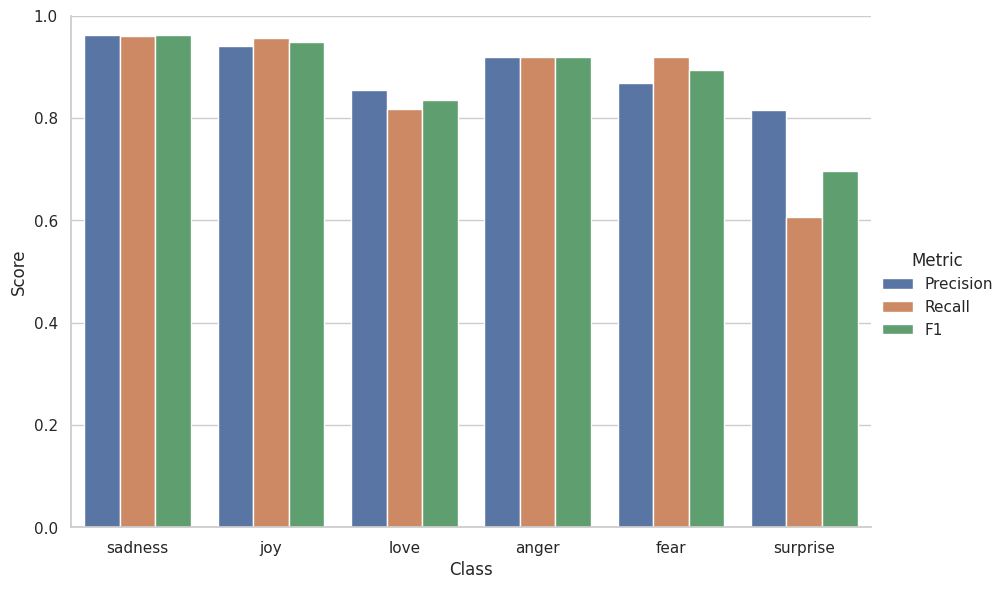

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

print("--- TEST SET EVALUATION ---")

preds = trainer_full.predict(tokenized_dataset["test"])
pred_labels = np.argmax(preds.predictions, axis=1)
true_labels = preds.label_ids

plot_confusion_matrix_func(pred_labels, true_labels, "complete_ft_confusion_matrix")

results_test = trainer_full.evaluate(tokenized_dataset["test"])
print(results_test)

plot_class_metrics(
    {
        "precision": results_test["eval_precision"],
        "recall": results_test["eval_recall"],
        "f1": results_test["eval_f1"]
    },
    dataset["train"].features["label"].names,
    "complete_ft_test_metrics.png"
)

with open("final_results.json", "w") as f:
    json.dump(results_test, f, indent=4)